In [2]:
import loaders
import pandas as pd
import numpy as np

In [3]:
bible = loaders.loader("bible")
references = loaders.loader("clustered_references")
references["ot_loc"] = bible.iloc[references["ostart"]].index

In [4]:
rev_refs = references[bible.iloc[references["nstart"]]["book"].values == "Revelation"]
bible["referencer"] = False
for start, end, cluster in rev_refs[["nstart", "nend", "cluster"]].values:
    bible.loc[bible.index[start:end], "referencer"] = True
rev = bible.loc["Revelation"]

In [5]:
top_10 = bible["str"].value_counts()[:10].index

In [6]:
for word in top_10:
    rmac = bible.query("str == @word").iloc[0]["rmac"]
    print(
        word,
        round((bible["str"] == word).sum() * 100 / len(bible), 2),
        rmac.split("-")[0],
    )

3588 14.3 t
2532 9.2 conj
846 4.56 d
1722 2.25 prep
4771 2.09 p
1473 1.95 p
1519 1.33 a
2962 1.32 n
1510 1.27 v
3739 1.12 r


In [7]:
bible["str"].isin(top_10).sum() / len(bible) * 100

39.378716808744954

<Axes: xlabel='nlen'>

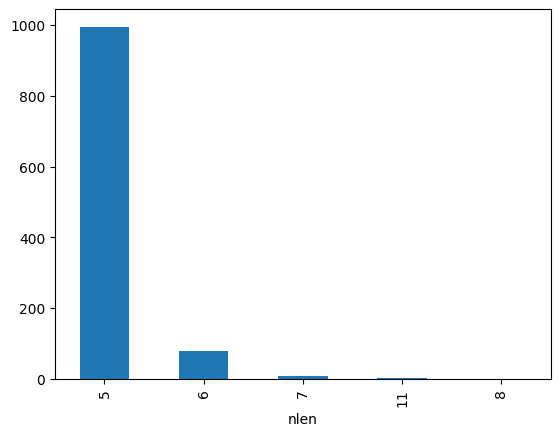

In [8]:
# distribution of reference lengths
rev_refs["nlen"].value_counts().plot.bar()

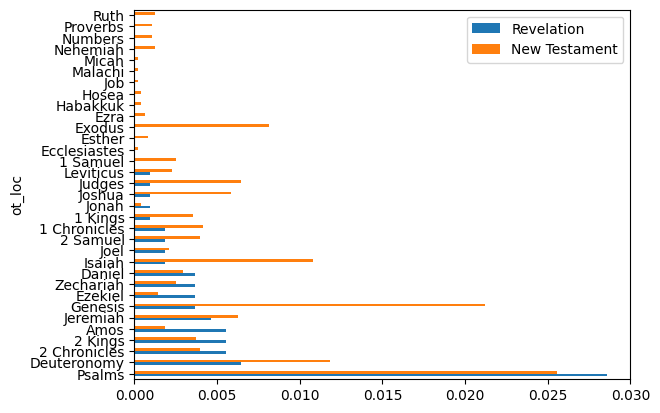

In [9]:
pd.DataFrame(
    {
        "Revelation": rev_refs.query("nlen > 5")["ot_loc"].str[0].value_counts()
        / len(rev_refs),
        "New Testament": references.query("(nlen > 5)")["ot_loc"].str[0].value_counts()
        / len(references),
    }
).sort_values("Revelation", ascending=False).plot.barh();

In [10]:
# proportion of words in revelation that are referencers
rev["referencer"].value_counts()

referencer
False    5226
True     4606
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt

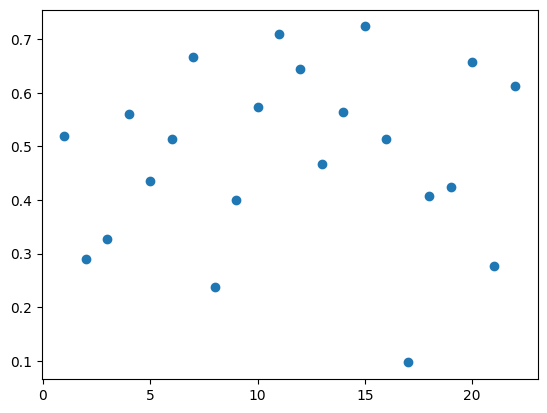

In [12]:
props = (
    rev.groupby(rev["chapter"])["referencer"]
    .apply(lambda g: sum(g) / len(g))
    .sort_index()
)
plt.scatter(props.index, props)

In [13]:
rev_refs["ot_loc"].str[0].value_counts()

ot_loc
Psalms          323
Genesis          65
Ezekiel          58
2 Chronicles     57
Amos             56
1 Samuel         54
Deuteronomy      44
Isaiah           43
Exodus           42
2 Kings          39
Jeremiah         36
Numbers          28
Daniel           25
2 Samuel         25
Judges           23
1 Chronicles     21
Leviticus        19
Joshua           18
Zechariah        18
1 Kings          16
Nehemiah         16
Nahum             8
Jonah             8
Hosea             8
Esther            5
Ezra              5
Joel              5
Job               4
Haggai            4
Proverbs          3
Ecclesiastes      3
Ruth              2
Malachi           1
Obadiah           1
Lamentations      1
Habakkuk          1
Name: count, dtype: int64

In [14]:
ot = bible.iloc[:475400]

In [15]:
reference_props = pd.DataFrame(columns=ot["book"].unique())
reference_props

,Genesis,Exodus,Leviticus,Numbers,Deuteronomy,Joshua,Judges,Ruth,1 Samuel,2 Samuel,...,Amos,Obadiah,Jonah,Micah,Nahum,Habakkuk,Zephaniah,Haggai,Zechariah,Malachi


In [16]:
for book, group in references.groupby(bible.iloc[references["nstart"]]["book"].values):
    book_len = len(bible.loc[book])
    reference_props.loc[book] = group.groupby(
        bible.iloc[group["ostart"]]["book"].values
    ).apply(lambda subg: sum(subg["nlen"]) / book_len)

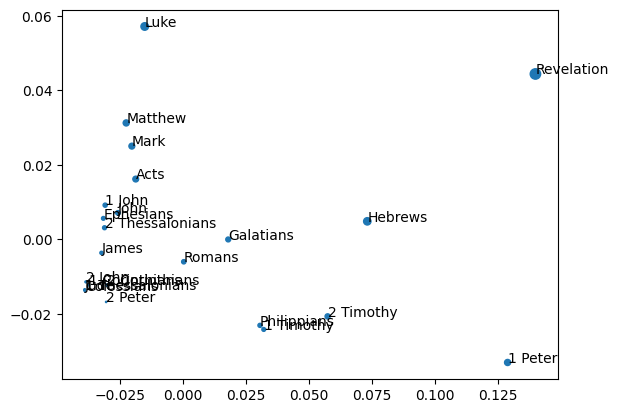

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(reference_props.fillna(0))
plt.scatter(X[:, 0], X[:, 1], s=reference_props.sum(axis=1).values * 100)
for book, pos in zip(reference_props.index, X):
    plt.annotate(book, pos)

In [19]:
import plotly.express as px

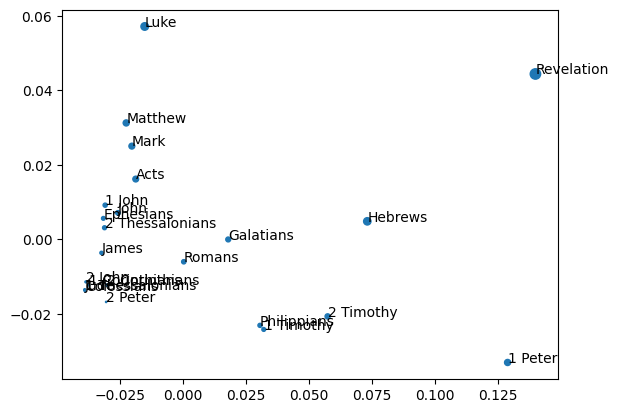

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(reference_props.fillna(0))
plt.scatter(X[:, 0], X[:, 1], s=reference_props.sum(axis=1).values * 100)
for book, pos in zip(reference_props.index, X):
    plt.annotate(book, pos)

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(reference_props.fillna(0))
px.scatter(
    x=X[:, 0],
    y=X[:, 1],
    size=reference_props.sum(axis=1).values * 100,
    text=reference_props.index,
    labels={"x": "PCA Component 1", "y": "PCA Component 2"},
    title="New Testament Use of Old Testament books",
)

# for book, pos in zip(reference_props.index, X):
#     plt.annotate(book, pos)